# Teste de treinamento de modelo para predição de Slump utilizando CatBoost

In [263]:
%%capture
!pip install catboost ipywidgets optuna shap

In [264]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, optuna, shap
import seaborn as sns
import pandas as pd
import numpy as np

### Montagem do drive

In [265]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [266]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_CatBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Cimento_kg_m3               106 non-null    float64 
 1   Agua_kg_m3                  106 non-null    float64 
 2   Metodo_Emp_Cod              106 non-null    int64   
 3   Usa_SP                      106 non-null    int64   
 4   Classe_Cim_OpA              106 non-null    int64   
 5   D_Max                       106 non-null    float64 
 6   vol_ar_aprisionado          106 non-null    float64 
 7   vol_aglomerante             106 non-null    float64 
 8   vol_argamassa               106 non-null    float64 
 9   fracao_vol_pasta            106 non-null    float64 
 10  agua_aglomerante_vol        106 non-null    float64 
 11  filer_sobre_cimento_vol     106 non-null    float64 
 12  agua_equivalente_vol        106 non-null    float64 
 13  indice_lubrificacao_

In [267]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [268]:
# 1. Separa 95% para treino e 5% para a teste (mantendo a proporção da coluna 'bins')
df_temp, df_test= train_test_split(
    df,
    test_size=0.05, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 95% restantes, divide em treino e validação, mantendo a proporção da coluna 'bins'
# Isso resulta em 70% do total para treino e 30% para validação
df_train, df_val = train_test_split(
    df_temp, 
    test_size=0.3,
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [269]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

Cimento_kg_m3                 0
Agua_kg_m3                    0
Metodo_Emp_Cod                0
Usa_SP                        0
Classe_Cim_OpA                0
D_Max                         0
vol_ar_aprisionado            0
vol_aglomerante               0
vol_argamassa                 0
fracao_vol_pasta              0
agua_aglomerante_vol          0
filer_sobre_cimento_vol       0
agua_equivalente_vol          0
indice_lubrificacao_global    0
rigidez_pasta                 0
yield_stress_proxy            0
fluido_lubrificante_total     0
fator_agua_finos              0
lubrificacao_efetiva          0
dtype: int64


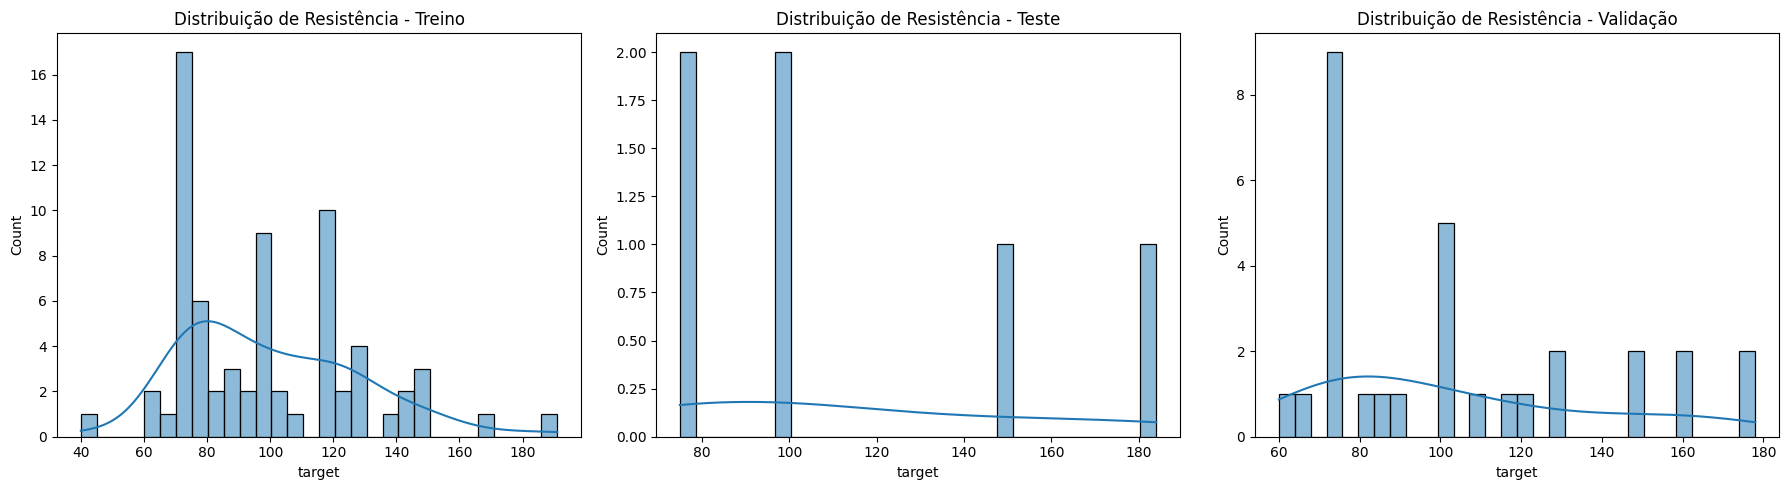

In [270]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Resistência - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Resistência - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Resistência - Validação')
plt.tight_layout()
plt.show()

In [271]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (70, 19)
X_test shape: (6, 19)
X_val shape: (30, 19)

X_train
Cimento_kg_m3: float64 (NAs: 0)
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Usa_SP: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
D_Max: float64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
vol_aglomerante: float64 (NAs: 0)
vol_argamassa: float64 (NAs: 0)
fracao_vol_pasta: float64 (NAs: 0)
agua_aglomerante_vol: float64 (NAs: 0)
filer_sobre_cimento_vol: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
indice_lubrificacao_global: float64 (NAs: 0)
rigidez_pasta: float64 (NAs: 0)
yield_stress_proxy: float64 (NAs: 0)
fluido_lubrificante_total: float64 (NAs: 0)
fator_agua_finos: float64 (NAs: 0)
lubrificacao_efetiva: float64 (NAs: 0)

X_test
Cimento_kg_m3: float64 (NAs: 0)
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Usa_SP: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
D_Max: float64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
vol_aglomerante: float64 (NAs: 0)
vol_argamassa:

In [272]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (70,)
y_test shape: (6,)
y_val shape: (30,)

y_train
target: int64 (NAs: 0)

y_test
target: int64 (NAs: 0)

y_val
target: int64 (NAs: 0)



In [592]:
# O mesmo dicionário de física que você já tem montado
regras_reologia_catboost = {
    'Cimento_kg_m3': 0,
    'Agua_kg_m3': 1,
    'Usa_SP': 1,
    'Classe_Cim_OpA': 0,
    'D_Max': 1,
    'vol_ar_aprisionado': 1,
    'vol_argamassa': 1,
    'vol_total': 0,  # ideal remover
    'fracao_vol_pasta': 1,
    'teor_pasta_relativo': 1,
    'filer_sobre_cimento_vol': 0,
    'agua_equivalente_vol': 1,
    'indice_lubrificacao_global': 1,
    'rigidez_pasta': -1,
    'yield_stress_proxy': -1,
    'fluido_lubrificante_total': 1,
    'fator_agua_finos': 1,
    'lubrificacao_efetiva': 1
}

hyper_params = {
    'iterations': 1200,
    'learning_rate': 0.03,
    'depth': 2,
    'l2_leaf_reg': 10,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 2,
    'random_strength': 1.5,
    'min_data_in_leaf': 6,
    'border_count': 32,
    'boosting_type': 'Ordered'
}

In [593]:
model = CatBoostRegressor(**hyper_params)

In [594]:
%%time
model.fit(X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,        # Salva apenas a melhor iteração, descartando o resto
    plot=True,                  # Renderiza o painel dinâmico em tempo real
    verbose=False
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CPU times: user 867 ms, sys: 70.7 ms, total: 938 ms
Wall time: 613 ms


CatBoostRegressor(bagging_temperature=2, boosting_type='Ordered', bootstrap_type='Bayesian', border_count=32, depth=2, eval_metric='RMSE', iterations=1200, l2_leaf_reg=10, learning_rate=0.03, loss_function='RMSE', min_data_in_leaf=6, random_seed=42, random_strength=1.5)

In [595]:
model.evals_result_['validation'].keys()

dict_keys(['RMSE'])

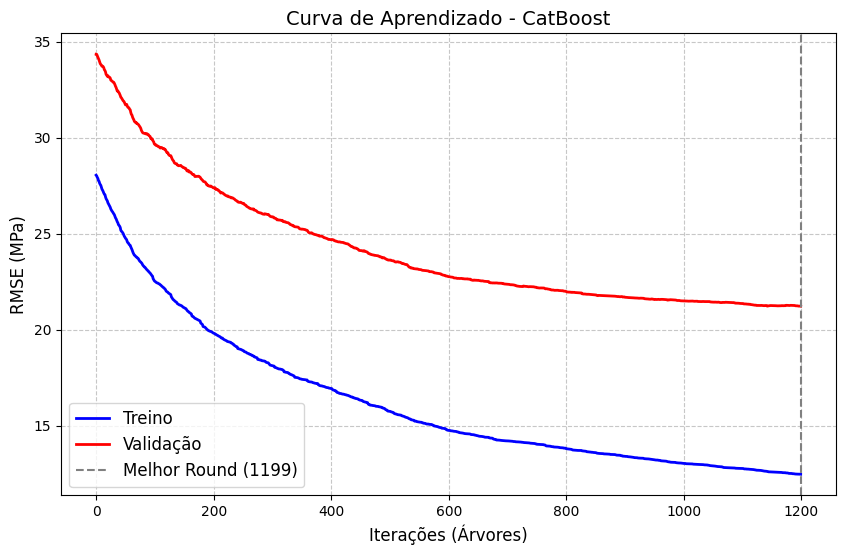

✅ Treinamento concluído. O modelo rebobinou automaticamente para o round 1199.
RMSE Final (Treino): 12.4799
RMSE Final (Validação): 21.2308


In [596]:
# 3. Extraindo os históricos gravados dentro do modelo
train_rmse = model.evals_result_['learn']['RMSE']
val_rmse = model.evals_result_['validation']['RMSE']
# Extraímos os dados do histórico interno do modelo treinado
treino_rmse = model.evals_result_['learn']['RMSE']
val_rmse = model.evals_result_['validation']['RMSE']
melhor_round = model.get_best_iteration()

# Criamos nosso próprio gráfico com Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(treino_rmse, label='Treino', color='blue', linewidth=2)
plt.plot(val_rmse, label='Validação', color='red', linewidth=2)

# Coloca uma linha vertical marcando onde foi o melhor round!
plt.axvline(x=melhor_round, color='gray', linestyle='--', label=f'Melhor Round ({melhor_round})')

plt.title('Curva de Aprendizado - CatBoost', fontsize=14)
plt.xlabel('Iterações (Árvores)', fontsize=12)
plt.ylabel('RMSE (MPa)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. O Veredito final
print(f"✅ Treinamento concluído. O modelo rebobinou automaticamente para o round {melhor_round}.")
print(f"RMSE Final (Treino): {treino_rmse[melhor_round]:.4f}")
print(f"RMSE Final (Validação): {val_rmse[melhor_round]:.4f}")

In [597]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      12.479949
⚠️  RMSE Validação (final):   21.230845
📈 Gap (Val - Train):        8.750897


In [598]:
# Fazer predições no conjunto de validação para avaliar o desempenho do modelo
y_pred = model.predict(X_val)
debug_df = X_val.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_val
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

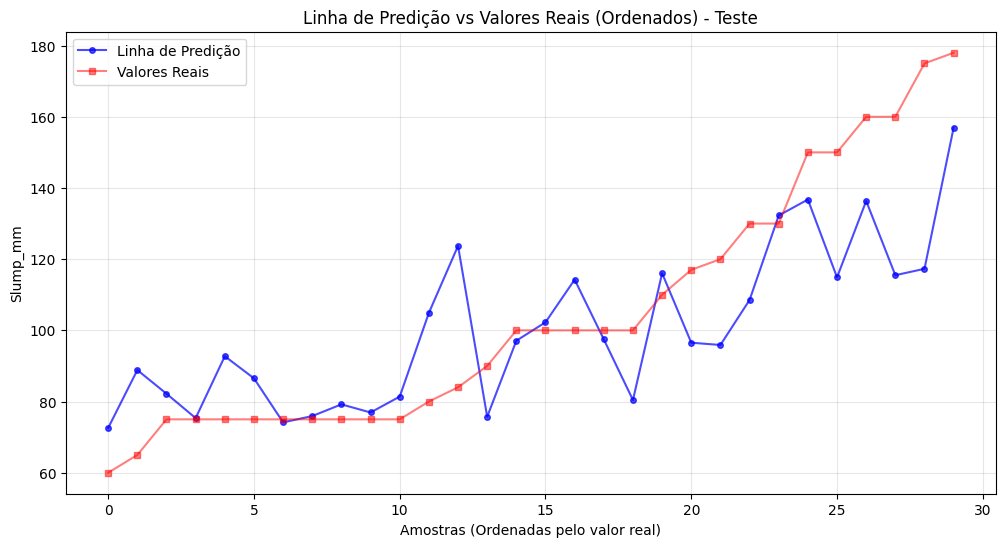

In [599]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump_mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [600]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 21.2308
mean_absolute_error: 15.9198
mean_absolute_percentage_error: 0.1475
R² Score: 61.4805


In [601]:
y_test_pred = model.predict(X_test)
test_df = X_test.copy()

test_df["pred"] = y_test_pred
test_df["ground_truth"] = y_test
test_df["residual"] = test_df["ground_truth"] - test_df["pred"]

Text(0.5, 1.0, 'Distribuição dos Resíduos - Teste')

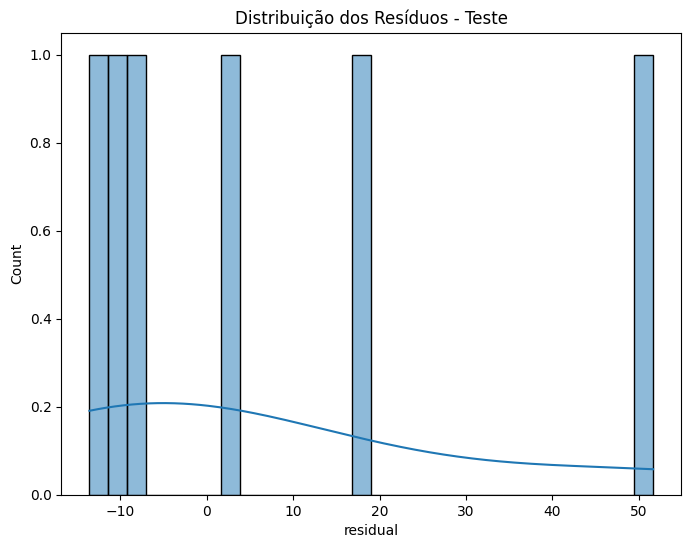

In [602]:
plt.figure(figsize=(8, 6))
sns.histplot(test_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos - Teste")

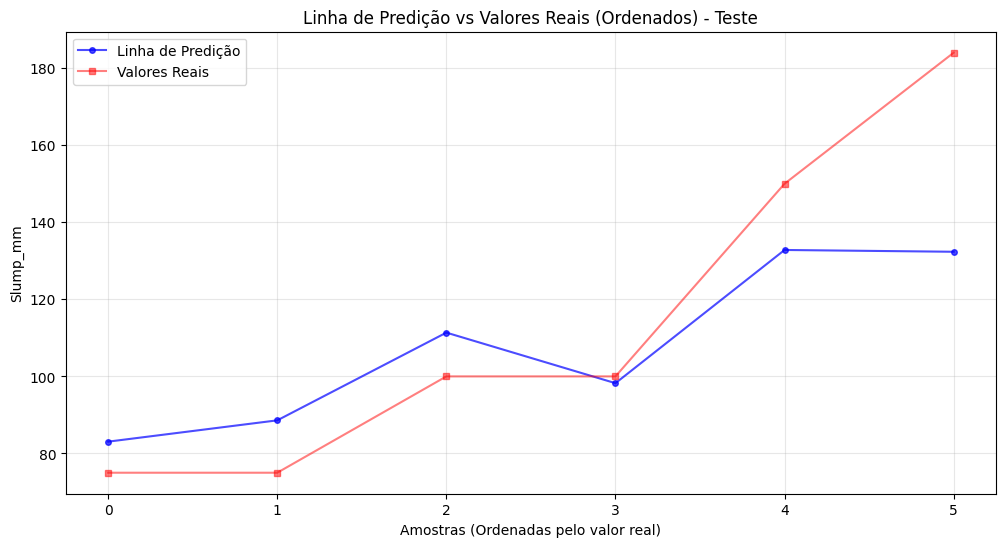

In [603]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
test_df = test_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(test_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, test_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, test_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump_mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [588]:
r2 = r2_score(test_df["ground_truth"], test_df["pred"])
rmse = root_mean_squared_error(test_df["ground_truth"], test_df["pred"])
mae = mean_absolute_error(test_df["ground_truth"], test_df["pred"])
mape = mean_absolute_percentage_error(test_df["ground_truth"], test_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 25.1103
mean_absolute_error: 18.9394
mean_absolute_percentage_error: 0.1495
R² Score: 60.7148


In [589]:
model_path = os.path.join(dirpath, "melhor_modelo_slump.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de features: {model.n_features_in_}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/slump/melhor_modelo_slump.json

📋 Informações do Modelo:
  • Número de features: 19


/tmp/ipykernel_7393/4065326967.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


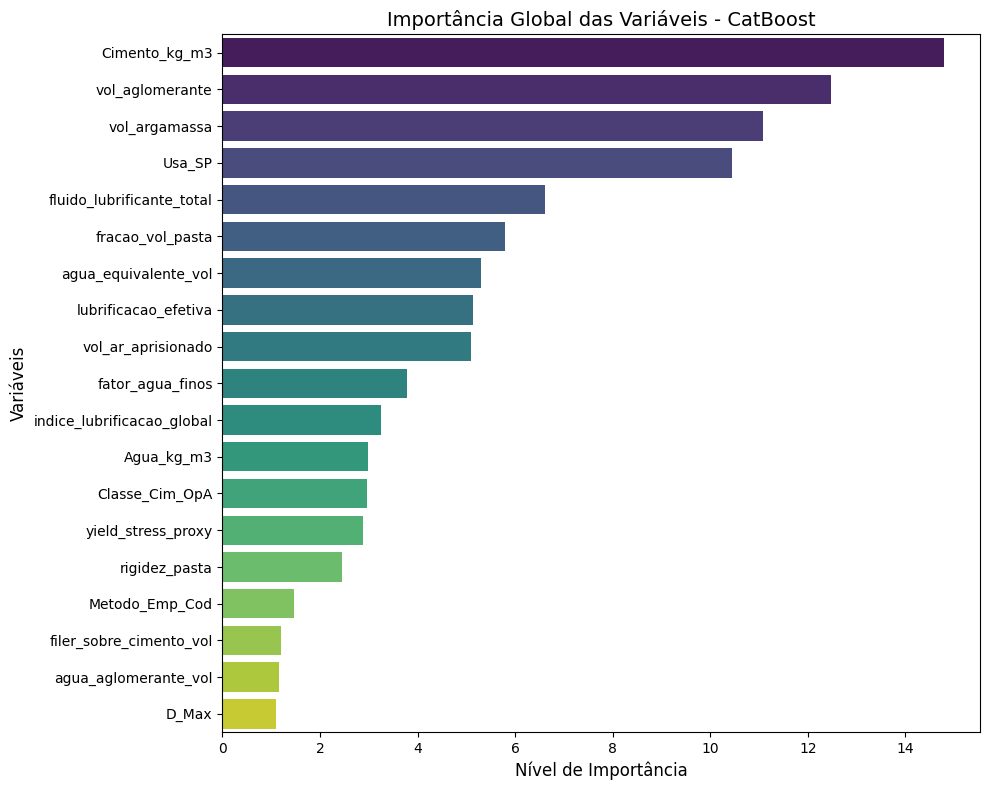

In [590]:
importancias = model.get_feature_importance()
features = X_train.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()

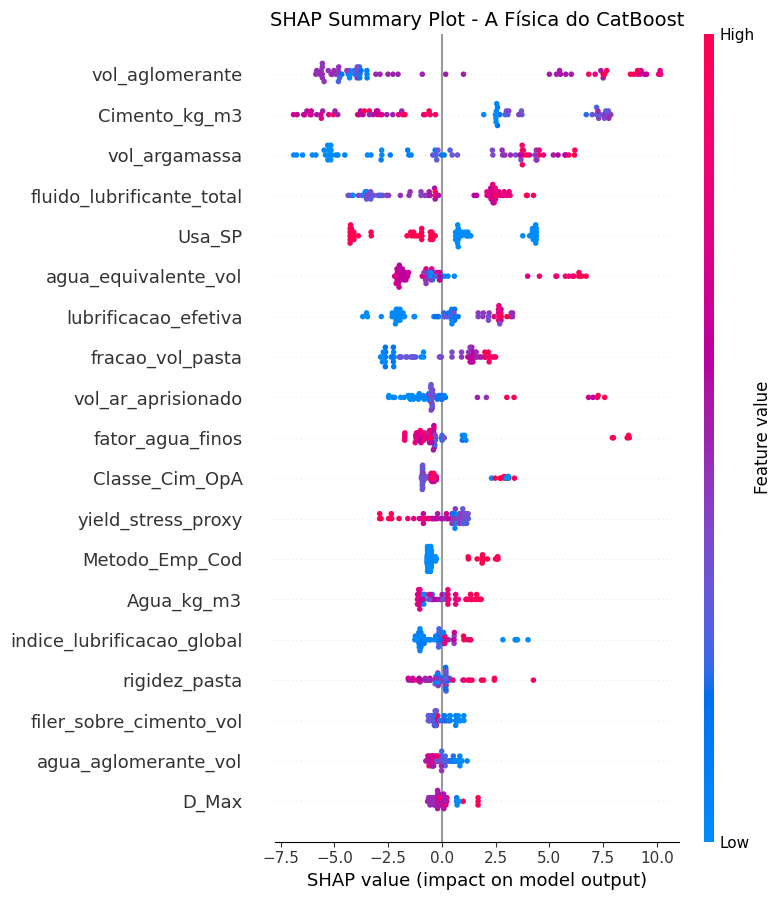

In [591]:
explainer_cat = shap.TreeExplainer(model)
shap_values_cat = explainer_cat.shap_values(X_train)

# Gera o gráfico de resumo (os famosos pontinhos coloridos)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot - A Física do CatBoost", fontsize=14)
shap.summary_plot(shap_values_cat, X_train, show=False)
plt.show()